# Perbandingan Model Regresi — Efikasi Diri & Tingkat Stres

Notebook ini membandingkan **3 varian model regresi linear** untuk menganalisis hubungan antara efikasi diri (X) dan tingkat stres mahasiswa (Y):

| Model | Formula | Keterangan |
|-------|---------|------------|
| **Model 1** | Y = f(X1…X10, Kelas, Gender) | 10 item individu sebagai prediktor |
| **Model 2** | Y = f(X_mean, Kelas, Gender) | X diagregasi menjadi 1 skor rata-rata |
| **Model 3** | Y_faktor = f(X_mean, Kelas, Gender) | 5 model terpisah per faktor Y |

## 1. Setup & Konfigurasi

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')

# --- Seed ---
SEED = 1
random.seed(SEED)
np.random.seed(SEED)

# --- Konstanta ---
OHE_COLS   = ['Gender', 'Kelas']
X_ITEM_COLS = [f'X{i}' for i in range(1, 11)]

FAKTOR_MAP = {
    'Y - Faktor 2': ['Y1',  'Y2',  'Y3',  'Y4',  'Y5' ],
    'Y - Faktor 3': ['Y6',  'Y7',  'Y8',  'Y9'        ],
    'Y - Faktor 5': ['Y10', 'Y11', 'Y12', 'Y13'       ],
    'Y - Faktor 6': ['Y14', 'Y15', 'Y16'              ],
    'Y - Faktor 7': ['Y17', 'Y18', 'Y19', 'Y20'       ],
}

print('✅ Setup selesai.')

✅ Setup selesai.


## 2. Load Data

In [59]:
var_y = pd.read_csv('var_y.csv')
df    = pd.read_csv('df.csv')

print(f'var_y : {var_y.shape}  →  {list(var_y.columns)}')
print(f'df    : {df.shape}    →  {list(df.columns)}')

var_y : (68, 20)  →  ['Y1', 'Y2', 'Y3', 'Y4', 'Y5', 'Y6', 'Y7', 'Y8', 'Y9', 'Y10', 'Y11', 'Y12', 'Y13', 'Y14', 'Y15', 'Y16', 'Y17', 'Y18', 'Y19', 'Y20']
df    : (68, 12)    →  ['Kelas', 'Gender', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10']


In [60]:
display(var_y.head(3))
display(df.head(3))

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20
0,2,5,5,5,4,5,5,5,5,3,3,2,5,4,4,2,5,4,3,5
1,2,2,4,3,4,2,4,4,4,3,4,4,4,2,2,2,5,4,5,5
2,3,2,5,4,2,3,4,5,3,3,4,4,4,3,3,2,3,3,3,2


,Kelas,Gender,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,LC09,Pria,3,3,2,2,3,3,2,3,2,2
1,LA09,Wanita,3,2,2,2,2,3,2,2,2,2
2,LB09,Pria,4,3,3,2,2,4,3,3,3,2


## 3. Analisis Populasi & Sampel

**Populasi Total B28 Data Science Kemanggisan (G. Anggrek): 127–167 mahasiswa**

| Kelas | Populasi |
|-------|----------|
| LA09  | 34       |
| LB09  | 35       |
| LC09  | 32       |
| LD09  | 32       |
| LE09  | 34       |

In [61]:
print('=== Distribusi Sampel ===')
print(df[['Kelas', 'Gender']].value_counts().sort_index().to_frame())

=== Distribusi Sampel ===
              count
Kelas Gender       
LA09  Pria       11
      Wanita      6
LB09  Pria       15
      Wanita      9
LC09  Pria       12
      Wanita      2
LD09  Pria        4
      Wanita      1
LE09  Pria        7
      Wanita      1


## 4. Eksplorasi Data (EDA)

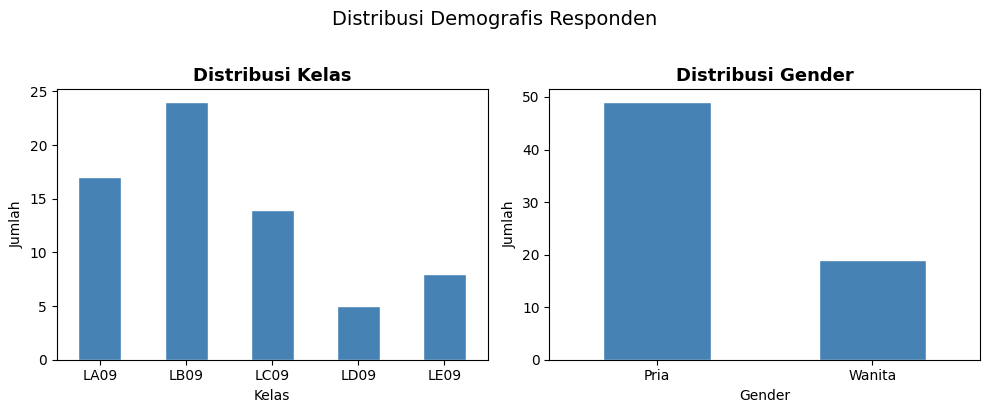

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col in zip(axes, ['Kelas', 'Gender']):
    df[col].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribusi {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Jumlah')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Distribusi Demografis Responden', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

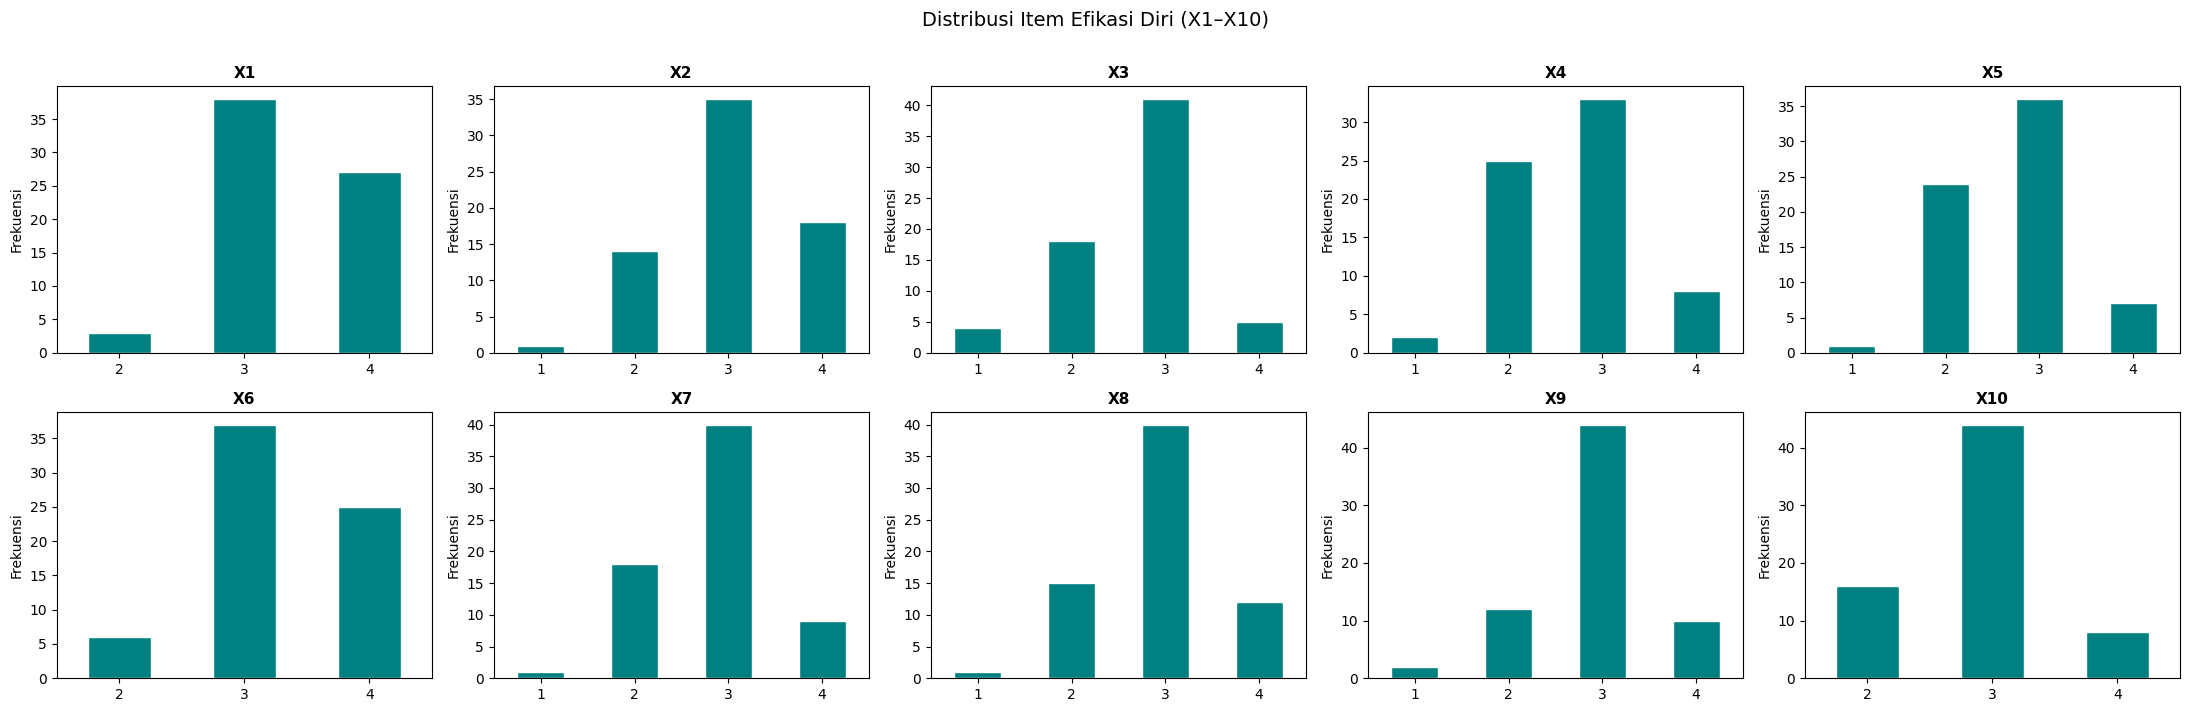

In [63]:
# Distribusi item X (efikasi diri)
var_x = df[X_ITEM_COLS]

fig, axes = plt.subplots(2, 5, figsize=(22, 7))
axes = axes.flatten()

for i, col in enumerate(var_x.columns):
    var_x[col].value_counts().sort_index().plot(kind='bar', ax=axes[i],
                                                color='teal', edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frekuensi')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Distribusi Item Efikasi Diri (X1–X10)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

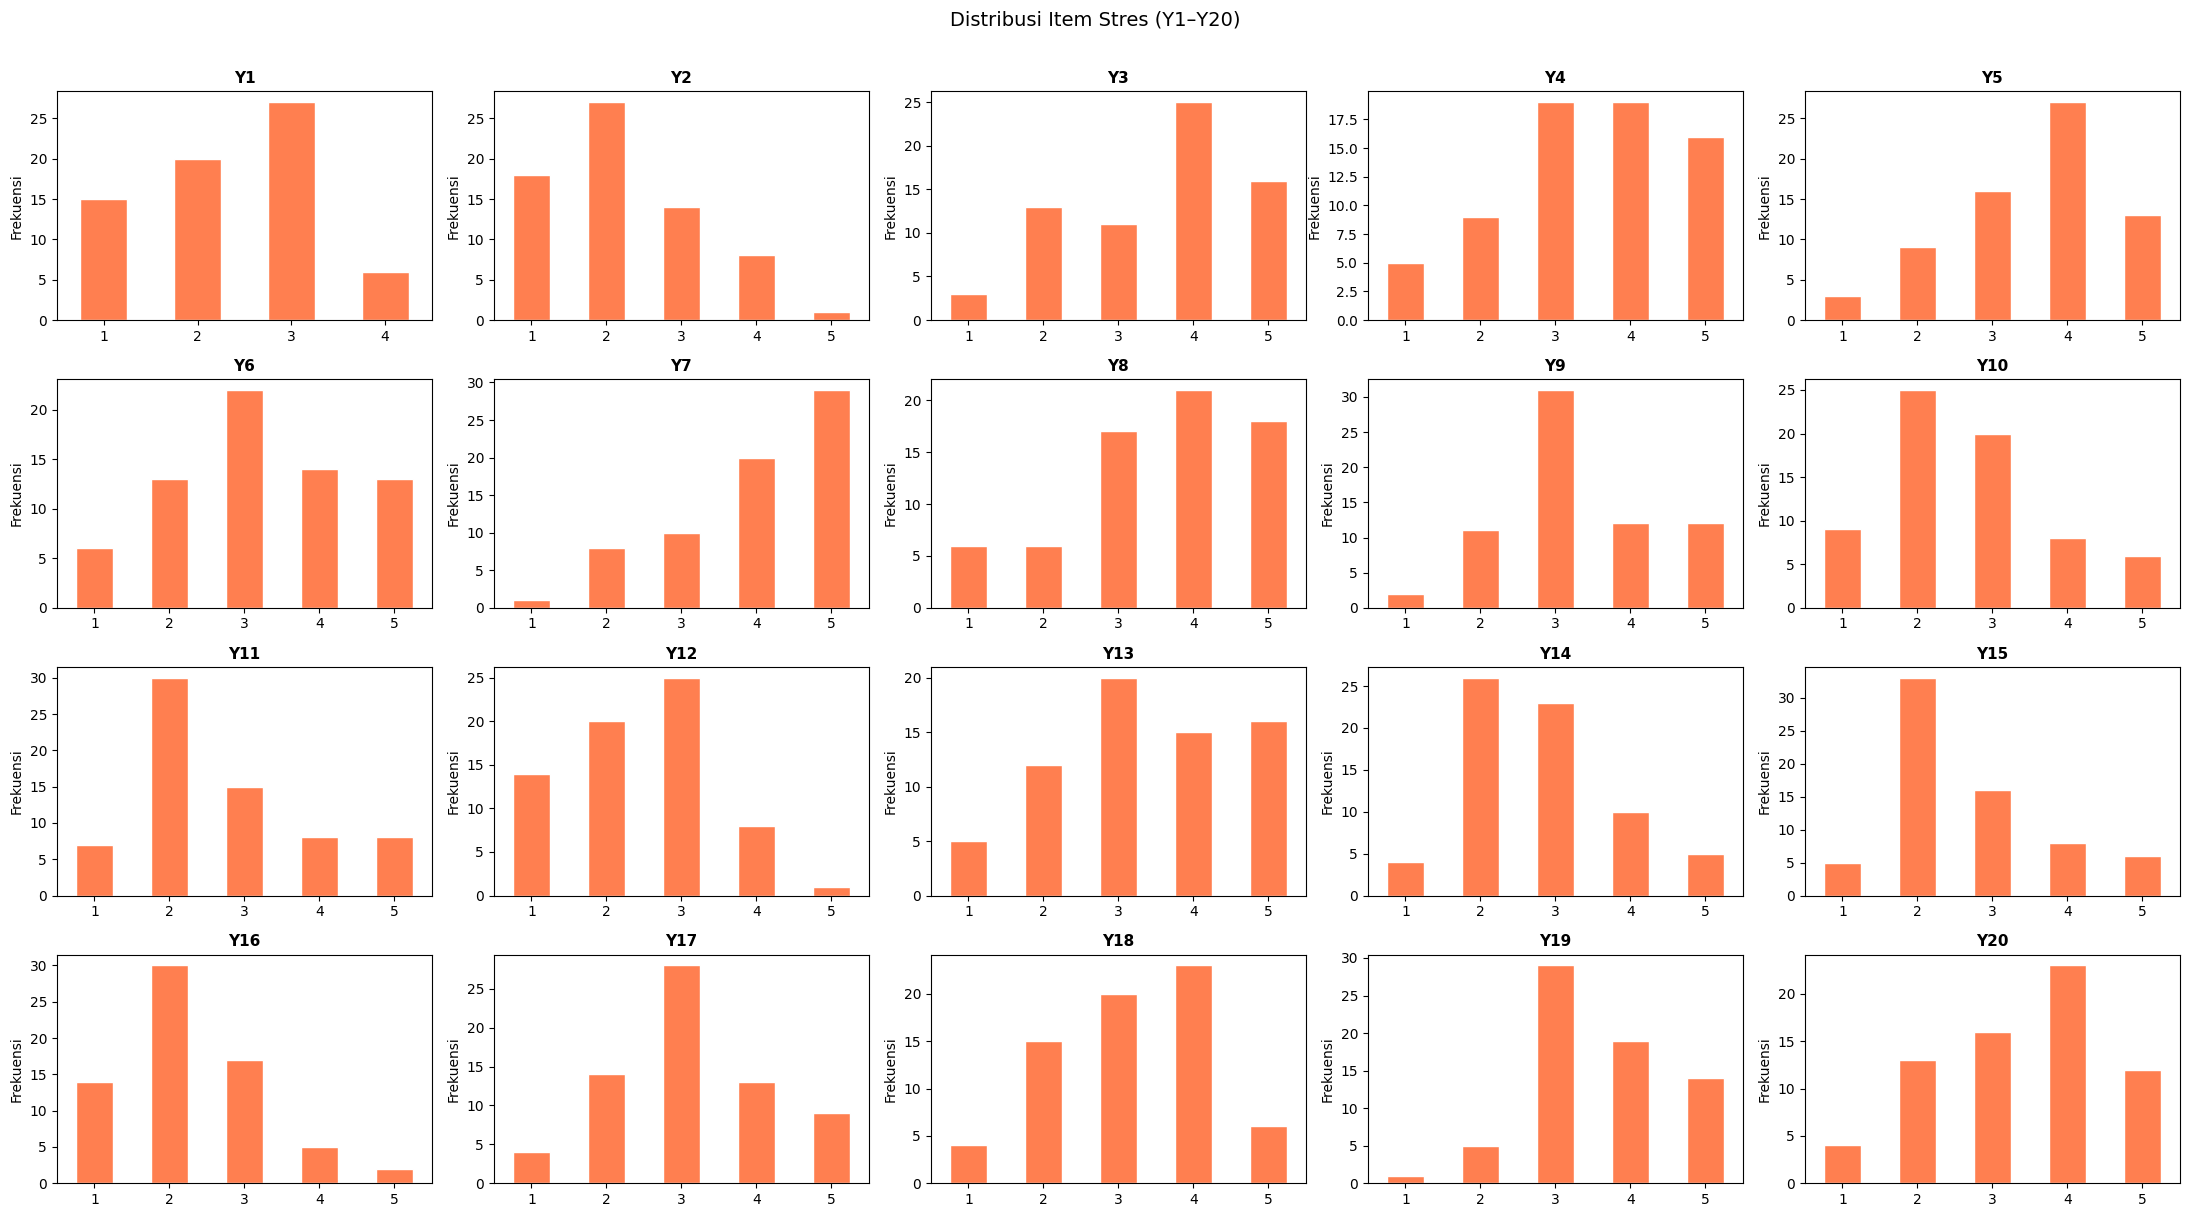

In [64]:
# Distribusi item Y (stres)
fig, axes = plt.subplots(4, 5, figsize=(22, 12))
axes = axes.flatten()

for i, col in enumerate(var_y.columns[:20]):
    var_y[col].value_counts().sort_index().plot(kind='bar', ax=axes[i],
                                                color='coral', edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frekuensi')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Distribusi Item Stres (Y1–Y20)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [65]:
# --- Target utama: rata-rata 20 item Y ---
df['target'] = var_y.sum(axis=1) / 20.0

# --- Faktor-faktor Y ---
for faktor, items in FAKTOR_MAP.items():
    df[faktor] = var_y[items].sum(axis=1) / float(len(items))

# --- Skor efikasi diri agregat ---
df['Efikasi Diri'] = df[X_ITEM_COLS].sum(axis=1) / 4.0   # skala 1-4 → dinormalisasi

print('Kolom setelah feature engineering:')
print(list(df.columns))

Kolom setelah feature engineering:
['Kelas', 'Gender', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'target', 'Y - Faktor 2', 'Y - Faktor 3', 'Y - Faktor 5', 'Y - Faktor 6', 'Y - Faktor 7', 'Efikasi Diri']


In [66]:
# ── Siapkan 3 dataframe untuk 3 varian model ──────────────────────────────────

FAKTOR_COLS = list(FAKTOR_MAP.keys())

# Model 1 — 10 item X + Kelas + Gender → target (Y mean)
df_1 = df.drop(columns=FAKTOR_COLS + ['Efikasi Diri'])

# Model 2 — X_mean + Kelas + Gender → target (Y mean)
df_2 = df.drop(columns=X_ITEM_COLS + FAKTOR_COLS)

# Model 3 — X_mean + Kelas + Gender → tiap Faktor Y (5 model)
df_3 = df.drop(columns=X_ITEM_COLS + ['target'])

for label, d in [('df_1', df_1), ('df_2', df_2), ('df_3', df_3)]:
    print(f'{label}: {d.shape}  |  kolom: {list(d.columns)}')
    print()

df_1: (68, 13)  |  kolom: ['Kelas', 'Gender', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'target']

df_2: (68, 4)  |  kolom: ['Kelas', 'Gender', 'target', 'Efikasi Diri']

df_3: (68, 8)  |  kolom: ['Kelas', 'Gender', 'Y - Faktor 2', 'Y - Faktor 3', 'Y - Faktor 5', 'Y - Faktor 6', 'Y - Faktor 7', 'Efikasi Diri']



## 6. Helper Functions

In [67]:
def build_pipeline() -> Pipeline:
    """Buat pipeline LinearRegression dengan OHE untuk kolom kategoris."""
    prep = ColumnTransformer([
        ('ohe',   OneHotEncoder(drop='first', sparse_output=False), OHE_COLS),
        ('pass',  'passthrough', slice(len(OHE_COLS), None))          # kolom numerik sisanya
    ])
    return Pipeline([('preprocessor', prep), ('lr', LinearRegression())])


def fit_and_evaluate(pipeline: Pipeline, X: pd.DataFrame, y: pd.Series,
                     label: str = '', cv: int = 5) -> dict:
    """Fit model, hitung metrik in-sample & CV-R², kembalikan dict hasil."""
    pipeline.fit(X, y)
    y_pred = pipeline.predict(X)

    cv_r2 = cross_val_score(pipeline, X, y, cv=cv, scoring='r2').mean()

    result = {
        'Label'  : label,
        'MAE'    : round(mean_absolute_error(y, y_pred),  4),
        'MSE'    : round(mean_squared_error(y, y_pred),   4),
        'RMSE'   : round(np.sqrt(mean_squared_error(y, y_pred)), 4),
        'R²'     : round(r2_score(y, y_pred),             4),
        'CV-R²'  : round(cv_r2,                           4),
    }
    return result


def get_coef_df(pipeline: Pipeline, X: pd.DataFrame) -> pd.DataFrame:
    """Ambil nama fitur & koefisien dari pipeline yang sudah di-fit."""
    # Dapatkan nama fitur output dari preprocessor
    try:
        ohe_names  = pipeline.named_steps['preprocessor']\
                         .named_transformers_['ohe']\
                         .get_feature_names_out(OHE_COLS)
    except Exception:
        ohe_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

    num_cols   = [c for c in X.columns if c not in OHE_COLS]
    feat_names = list(ohe_names) + num_cols

    coef = pipeline.named_steps['lr'].coef_
    return pd.DataFrame({'Fitur': feat_names[:len(coef)],
                         'Koefisien (×100)': coef[:len(feat_names)] * 100})\
             .sort_index()


def print_metrics(result: dict):
    print(f"  MAE   : {result['MAE']}")
    print(f"  MSE   : {result['MSE']}")
    print(f"  RMSE  : {result['RMSE']}")
    print(f"  R²    : {result['R²']}")
    print(f"  CV-R² : {result['CV-R²']}  (5-fold)")


print('✅ Helper functions siap.')

✅ Helper functions siap.


## 7. Model 1 — 10 Item X + Kelas + Gender → Y Mean

$$Y = \beta_0 + \beta_1 X_1 + \cdots + \beta_{10} X_{10} + \beta_{11}\,\text{Kelas} + \beta_{12}\,\text{Gender}$$

In [68]:
X1 = df_1.drop(columns=['target'])
y1 = df_1['target']

# Reorder: OHE_COLS dulu, lalu numerik
X1 = X1[OHE_COLS + [c for c in X1.columns if c not in OHE_COLS]]

pipe1    = build_pipeline()
result1  = fit_and_evaluate(pipe1, X1, y1, label='Model 1')

print('=== Model 1 – Metrik ===')
print_metrics(result1)

=== Model 1 – Metrik ===
  MAE   : 0.3442
  MSE   : 0.2057
  RMSE  : 0.4536
  R²    : 0.3235
  CV-R² : -0.4023  (5-fold)


In [69]:
coef1 = get_coef_df(pipe1, X1)
print('=== Model 1 – Koefisien ===')
display(coef1)

=== Model 1 – Koefisien ===


,Fitur,Koefisien (×100)
0,Gender_Wanita,17.858581
1,Kelas_LB09,5.319289
2,Kelas_LC09,15.455137
3,Kelas_LD09,-4.455368
4,Kelas_LE09,-9.819734
5,X1,37.985052
6,X2,-0.300561
7,X3,-16.896740
8,X4,5.489342
9,X5,7.963638


## 8. Model 2 — X Mean + Kelas + Gender → Y Mean

$$Y = \beta_0 + \beta_1\,X_{\text{mean}} + \beta_2\,\text{Kelas} + \beta_3\,\text{Gender}$$

In [70]:
X2 = df_2.drop(columns=['target'])
y2 = df_2['target']

X2 = X2[OHE_COLS + [c for c in X2.columns if c not in OHE_COLS]]

pipe2   = build_pipeline()
result2 = fit_and_evaluate(pipe2, X2, y2, label='Model 2')

print('=== Model 2 – Metrik ===')
print_metrics(result2)

=== Model 2 – Metrik ===
  MAE   : 0.3895
  MSE   : 0.2544
  RMSE  : 0.5044
  R²    : 0.1636
  CV-R² : -0.0543  (5-fold)


In [71]:
coef2 = get_coef_df(pipe2, X2)
print('=== Model 2 – Koefisien ===')
display(coef2)

=== Model 2 – Koefisien ===


,Fitur,Koefisien (×100)
0,Gender_Wanita,19.688851
1,Kelas_LB09,0.393550
2,Kelas_LC09,30.084593
3,Kelas_LD09,-2.383342
4,Kelas_LE09,-10.850903
5,Efikasi Diri,-14.769218


## 9. Model 3 — X Mean + Kelas + Gender → Tiap Faktor Y

$$Y_{\text{faktor}_k} = \beta_0 + \beta_1\,X_{\text{mean}} + \beta_2\,\text{Kelas} + \beta_3\,\text{Gender}, \quad k \in \{2,3,5,6,7\}$$

In [72]:
X3 = df_3.drop(columns=FAKTOR_COLS)
X3 = X3[OHE_COLS + [c for c in X3.columns if c not in OHE_COLS]]

results3 = {}   # faktor → dict hasil
pipes3   = {}   # faktor → pipeline yang sudah fit

for faktor in FAKTOR_COLS:
    y_k        = df_3[faktor]
    pipe_k     = build_pipeline()
    result_k   = fit_and_evaluate(pipe_k, X3, y_k, label=faktor)
    results3[faktor] = result_k
    pipes3[faktor]   = pipe_k
    print(f'\n=== {faktor} ===')
    print_metrics(result_k)


=== Y - Faktor 2 ===
  MAE   : 0.5592
  MSE   : 0.5189
  RMSE  : 0.7203
  R²    : 0.1561
  CV-R² : -0.1182  (5-fold)

=== Y - Faktor 3 ===
  MAE   : 0.6102
  MSE   : 0.53
  RMSE  : 0.728
  R²    : 0.1187
  CV-R² : -0.3413  (5-fold)

=== Y - Faktor 5 ===
  MAE   : 0.6186
  MSE   : 0.5957
  RMSE  : 0.7718
  R²    : 0.0523
  CV-R² : -0.4604  (5-fold)

=== Y - Faktor 6 ===
  MAE   : 0.6167
  MSE   : 0.666
  RMSE  : 0.8161
  R²    : 0.0548
  CV-R² : -0.3513  (5-fold)

=== Y - Faktor 7 ===
  MAE   : 0.5213
  MSE   : 0.4658
  RMSE  : 0.6825
  R²    : 0.2271
  CV-R² : 0.1047  (5-fold)


In [73]:
# Koefisien masing-masing sub-model
for faktor, pipe_k in pipes3.items():
    print(f'\n--- Koefisien: {faktor} ---')
    display(get_coef_df(pipe_k, X3))


--- Koefisien: Y - Faktor 2 ---


,Fitur,Koefisien (×100)
0,Gender_Wanita,13.362330
1,Kelas_LB09,-4.786880
2,Kelas_LC09,50.306692
3,Kelas_LD09,11.879654
4,Kelas_LE09,3.062939
5,Efikasi Diri,-22.085639



--- Koefisien: Y - Faktor 3 ---


,Fitur,Koefisien (×100)
0,Gender_Wanita,44.172952
1,Kelas_LB09,2.848765
2,Kelas_LC09,36.660178
3,Kelas_LD09,13.743105
4,Kelas_LE09,-7.410012
5,Efikasi Diri,-11.153344



--- Koefisien: Y - Faktor 5 ---


,Fitur,Koefisien (×100)
0,Gender_Wanita,18.317803
1,Kelas_LB09,31.326504
2,Kelas_LC09,11.751779
3,Kelas_LD09,21.834318
4,Kelas_LE09,13.946602
5,Efikasi Diri,-8.315222



--- Koefisien: Y - Faktor 6 ---


,Fitur,Koefisien (×100)
0,Gender_Wanita,-6.785037
1,Kelas_LB09,21.877456
2,Kelas_LC09,21.244253
3,Kelas_LD09,-17.152808
4,Kelas_LE09,-9.368780
5,Efikasi Diri,-13.087013



--- Koefisien: Y - Faktor 7 ---


,Fitur,Koefisien (×100)
0,Gender_Wanita,24.339365
1,Kelas_LB09,-42.632013
2,Kelas_LC09,23.194455
3,Kelas_LD09,-49.479096
4,Kelas_LE09,-57.593190
5,Efikasi Diri,-16.955214


## 10. Perbandingan Semua Model

In [74]:
# Kumpulkan semua hasil
all_results = [result1, result2] + list(results3.values())
comparison_df = pd.DataFrame(all_results).set_index('Label')

print('=== Tabel Perbandingan Metrik ===')
display(comparison_df.style
    .background_gradient(subset=['R²', 'CV-R²'], cmap='RdYlGn')
    .background_gradient(subset=['MAE', 'RMSE'],  cmap='RdYlGn_r')
    .format('{:.4f}')
)

=== Tabel Perbandingan Metrik ===


,MAE,MSE,RMSE,R²,CV-R²
Label,,,,,
Model 1,0.3442,0.2057,0.4536,0.3235,-0.4023
Model 2,0.3895,0.2544,0.5044,0.1636,-0.0543
Y - Faktor 2,0.5592,0.5189,0.7203,0.1561,-0.1182
Y - Faktor 3,0.6102,0.5300,0.7280,0.1187,-0.3413
Y - Faktor 5,0.6186,0.5957,0.7718,0.0523,-0.4604
Y - Faktor 6,0.6167,0.6660,0.8161,0.0548,-0.3513
Y - Faktor 7,0.5213,0.4658,0.6825,0.2271,0.1047


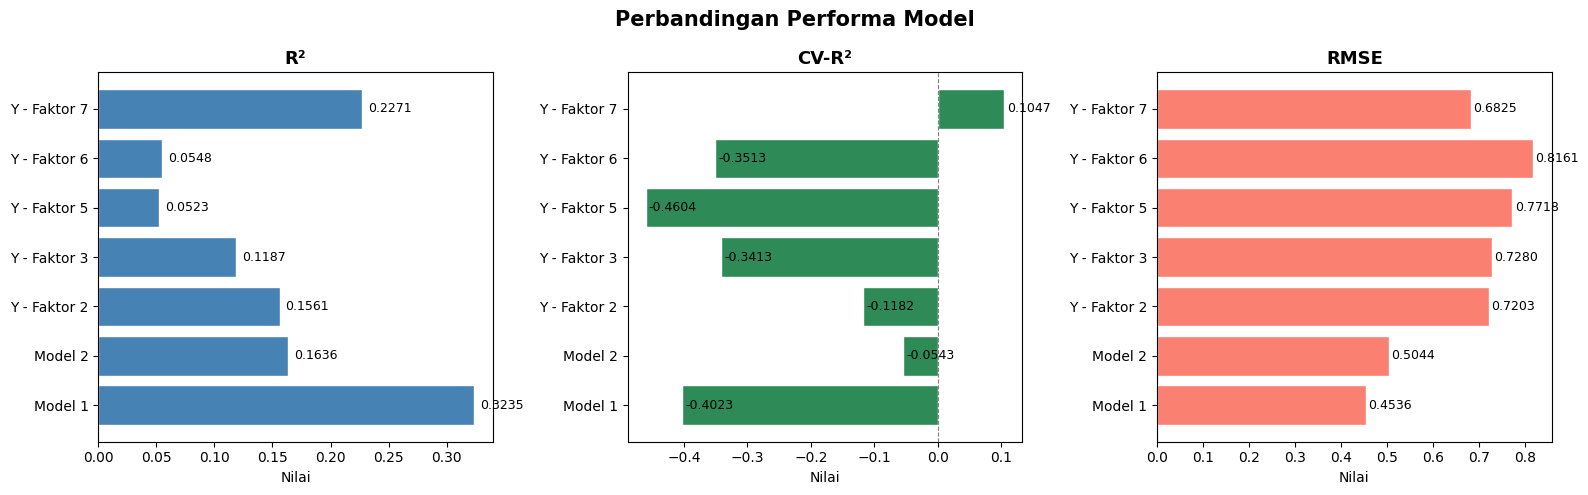

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_to_plot = ['R²', 'CV-R²', 'RMSE']
colors = ['steelblue', 'seagreen', 'salmon']

for ax, metric, color in zip(axes, metrics_to_plot, colors):
    vals   = comparison_df[metric]
    bars   = ax.barh(vals.index, vals.values, color=color, edgecolor='white')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel('Nilai')
    ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Perbandingan Performa Model', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

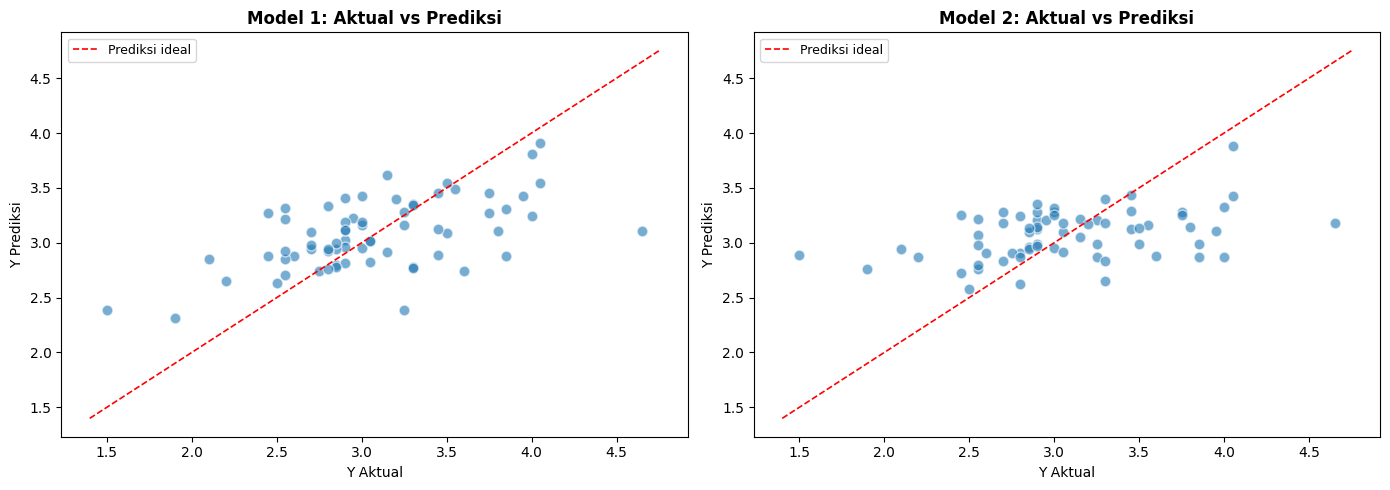

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, pipe, X_used, y_used) in zip(
        axes,
        [('Model 1', pipe1, X1, y1),
         ('Model 2', pipe2, X2, y2)]):

    y_pred = pipe.predict(X_used)
    ax.scatter(y_used, y_pred, alpha=0.6, edgecolors='w', s=60)
    lims = [min(y_used.min(), y_pred.min()) - 0.1,
            max(y_used.max(), y_pred.max()) + 0.1]
    ax.plot(lims, lims, 'r--', linewidth=1.2, label='Prediksi ideal')
    ax.set_title(f'{label}: Aktual vs Prediksi', fontsize=12, fontweight='bold')
    ax.set_xlabel('Y Aktual')
    ax.set_ylabel('Y Prediksi')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 11. Ringkasan & Rekomendasi

Gunakan tabel di bawah sebagai panduan memilih model yang sesuai dengan tujuan analisis.

| Model | Kelebihan | Keterbatasan | Cocok untuk |
|-------|-----------|--------------|-------------|
| **Model 1** | Detail pengaruh tiap item X | Banyak prediktor → risiko overfitting dengan n kecil | Eksplorasi pengaruh per item |
| **Model 2** | Parsimonious, interpretasi mudah | Kehilangan variasi antar item | Laporan & presentasi |
| **Model 3** | Pengaruh X terhadap tiap dimensi Y  (Bonferroni Correction) | Lima model terpisah sulit dibandingkan langsung | Analisis per faktor stres |